# Phase 3: Downloaded Image Subset Exploratory Data Analysis

This notebook performs descriptive checks and visual inspection on the reconciled local image subset. It does not train models or persist transformed images.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from IPython.display import Markdown, display

def find_repository_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / '.git').exists():
            return candidate
    raise FileNotFoundError('Could not find repository root containing .git.')

REPOSITORY_ROOT = find_repository_root(Path.cwd())
MANIFEST_PATH = REPOSITORY_ROOT / 'data/processed/image_subset_manifest.parquet'
manifest = pd.read_parquet(MANIFEST_PATH)
if 'local_image_path' not in manifest.columns:
    raise ValueError('The reconciled manifest must contain local_image_path.')
LABEL_COLUMNS = ['Cardiomegaly_label', 'Edema_label', 'Atelectasis_label', 'Pleural Effusion_label', 'Consolidation_label']
SAMPLE_SIZE = 500
sample_df = manifest.sample(n=min(SAMPLE_SIZE, len(manifest)), random_state=42).copy()
print(f'Repository root: {REPOSITORY_ROOT}')
print(f'Reconciled manifest rows: {len(manifest):,}')
print(f'Fixed-seed image sample rows: {len(sample_df):,}')

Repository root: C:\Users\ismai\OneDrive\Documenti\Repo\Medical-AI-Clinical-Decision-Support
Reconciled manifest rows: 12,434
Fixed-seed image sample rows: 500


## Section 1: Image Properties

In [2]:
property_records = []
for local_path in sample_df['local_image_path']:
    path = Path(local_path)
    with Image.open(path) as image:
        property_records.append({'local_image_path': str(path), 'width': image.width, 'height': image.height, 'mode': image.mode, 'file_size_mb': path.stat().st_size / (1024 ** 2)})
image_properties = pd.DataFrame(property_records)
image_properties.describe(include='all')

,local_image_path,width,height,mode,file_size_mb
count,500,500.000000,500.000000,500,500.000000
unique,500,NaN,NaN,1,NaN
top,C:\Users\ismai\OneDrive\Documenti\Repo\Medical...,NaN,NaN,L,NaN
freq,1,NaN,NaN,500,NaN
mean,NaN,2822.858000,2378.574000,NaN,3.609783
std,NaN,465.926433,324.806359,NaN,1.288062
min,NaN,1685.000000,1611.000000,NaN,0.982862
25%,NaN,2828.000000,2320.000000,NaN,2.935562
50%,NaN,2828.000000,2320.000000,NaN,3.394507
75%,NaN,3060.750000,2709.750000,NaN,4.340297


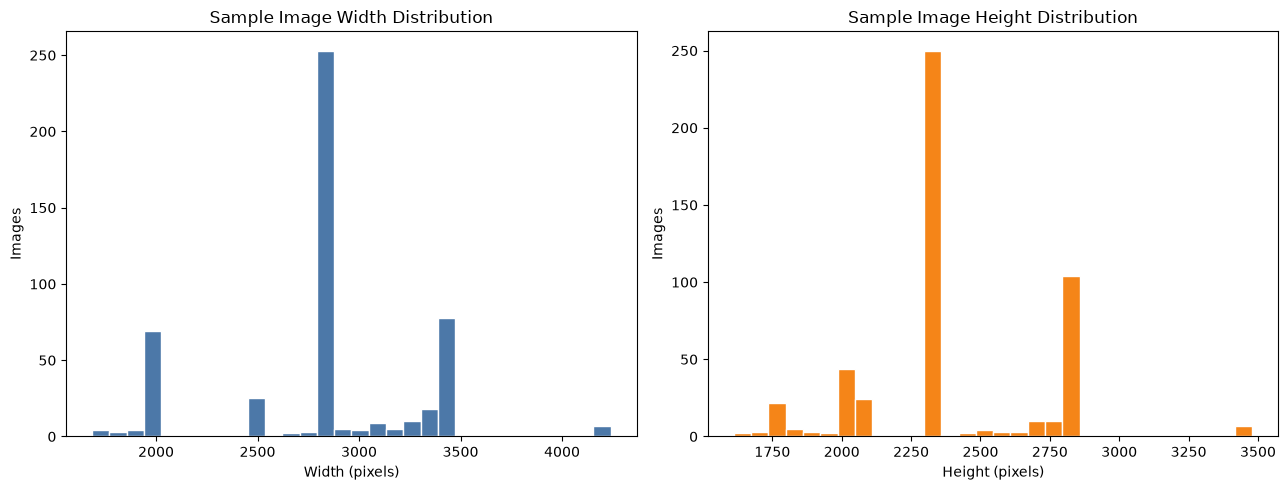

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(image_properties['width'], bins=30, color='#4C78A8', edgecolor='white')
axes[0].set(title='Sample Image Width Distribution', xlabel='Width (pixels)', ylabel='Images')
axes[1].hist(image_properties['height'], bins=30, color='#F58518', edgecolor='white')
axes[1].set(title='Sample Image Height Distribution', xlabel='Height (pixels)', ylabel='Images')
plt.tight_layout()
plt.show()

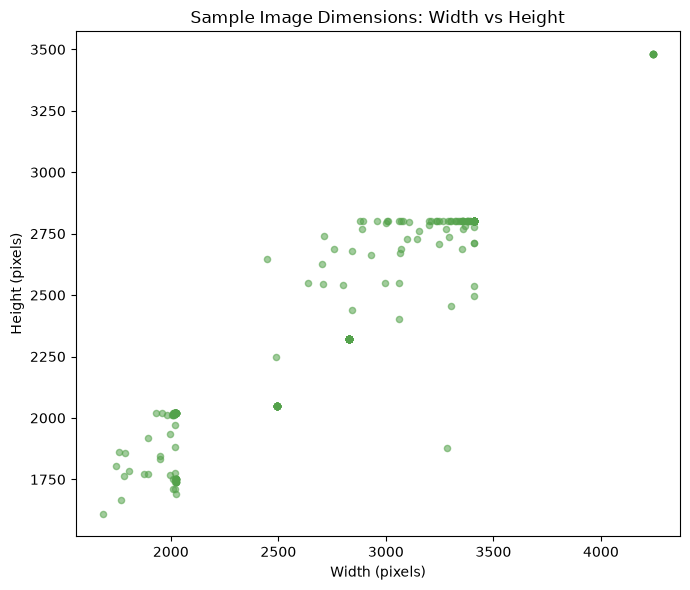

In [4]:
plt.figure(figsize=(7, 6))
plt.scatter(image_properties['width'], image_properties['height'], alpha=0.55, s=20, color='#54A24B')
plt.title('Sample Image Dimensions: Width vs Height')
plt.xlabel('Width (pixels)')
plt.ylabel('Height (pixels)')
plt.tight_layout()
plt.show()

In [5]:
mode_counts = image_properties['mode'].value_counts().rename_axis('PIL mode').to_frame('Image count')
display(mode_counts)
non_grayscale = image_properties.loc[image_properties['mode'] != 'L', 'local_image_path'].tolist()
if non_grayscale:
    print(f'WARNING: {len(non_grayscale)} sampled images are not single-channel grayscale (L).')
    print(*non_grayscale, sep='\n')
else:
    print('All sampled images are single-channel grayscale (L).')

,Image count
PIL mode,
L,500


All sampled images are single-channel grayscale (L).


In [6]:
file_size_summary = image_properties['file_size_mb'].agg(['min', 'max', 'mean']).rename('MB')
display(file_size_summary.to_frame())

,MB
min,0.982862
max,8.992161
mean,3.609783


**Section 1 summary.** The fixed 500-image sample contains only single-channel `L` images, as expected for grayscale chest X-rays. Width ranges from 1,685 to 4,240 pixels and height from 1,611 to 3,480 pixels; sampled file sizes range from 0.98 MB to 8.99 MB (mean 3.61 MB).

## Section 2: Corrupt File and Quality Check

In [7]:
corrupt_files = []
for index, local_path in enumerate(manifest['local_image_path'], start=1):
    try:
        # verify() checks file integrity; reopening and load() forces pixel decoding.
        with Image.open(local_path) as image:
            image.verify()
        with Image.open(local_path) as image:
            image.load()
    except Exception as error:
        corrupt_files.append({'local_image_path': str(local_path), 'error': str(error)})
    if index % 1000 == 0:
        print(f'Checked {index:,}/{len(manifest):,} images...')

corrupt_df = pd.DataFrame(corrupt_files, columns=['local_image_path', 'error'])
print(f'Corrupt files found: {len(corrupt_df)}')
display(corrupt_df)

Checked 1,000/12,434 images...


Checked 2,000/12,434 images...


Checked 3,000/12,434 images...


Checked 4,000/12,434 images...


Checked 5,000/12,434 images...


...

Checked 10,000/12,434 images...


Checked 11,000/12,434 images...


Checked 12,000/12,434 images...


Corrupt files found: 0


,local_image_path,error


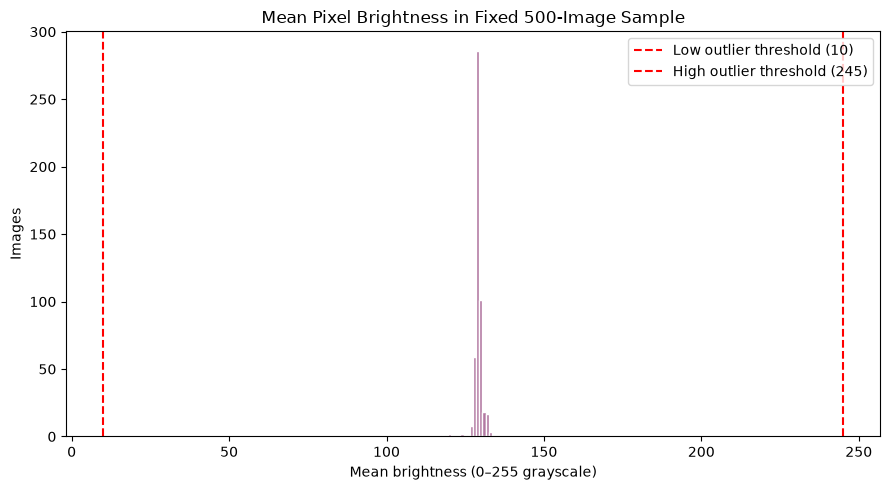

In [8]:
brightness_records = []
for local_path in sample_df['local_image_path']:
    with Image.open(local_path) as image:
        pixels = np.asarray(image.convert('L'), dtype=np.uint8)
        brightness_records.append({'local_image_path': str(local_path), 'mean_brightness': pixels.mean()})
brightness_df = pd.DataFrame(brightness_records)
plt.figure(figsize=(9, 5))
plt.hist(brightness_df['mean_brightness'], bins=30, color='#B279A2', edgecolor='white')
plt.axvline(10, color='red', linestyle='--', label='Low outlier threshold (10)')
plt.axvline(245, color='red', linestyle='--', label='High outlier threshold (245)')
plt.title('Mean Pixel Brightness in Fixed 500-Image Sample')
plt.xlabel('Mean brightness (0–255 grayscale)')
plt.ylabel('Images')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
brightness_outliers = brightness_df.loc[(brightness_df['mean_brightness'] < 10) | (brightness_df['mean_brightness'] > 245)]
print(f'Brightness outliers (<10 or >245): {len(brightness_outliers)}')
display(brightness_outliers)

Brightness outliers (<10 or >245): 0


,local_image_path,mean_brightness


In [10]:
display(Markdown(f'**Section 2 summary.** Full verify-and-load checks found **{len(corrupt_df):,} corrupt files** among {len(manifest):,} reconciled images. The 500-image brightness sample has a mean of {brightness_df.mean_brightness.mean():.2f}/255 and {len(brightness_outliers)} values outside the <10 or >245 quality thresholds.'))

**Section 2 summary.** Full verify-and-load checks found **0 corrupt files** among 12,434 reconciled images. The 500-image brightness sample has a mean of 129.11/255 and 0 values outside the <10 or >245 quality thresholds.

## Section 3: Per-Label Visual Sampling

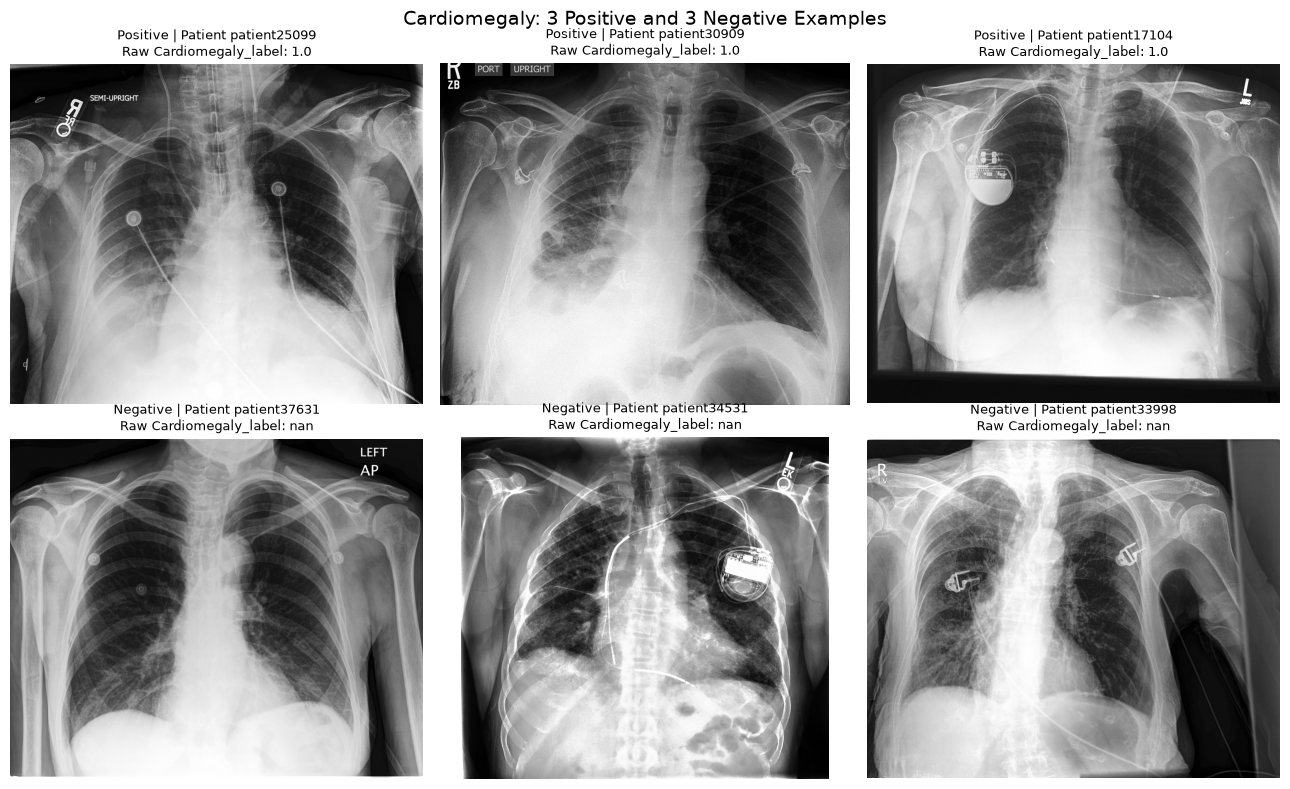

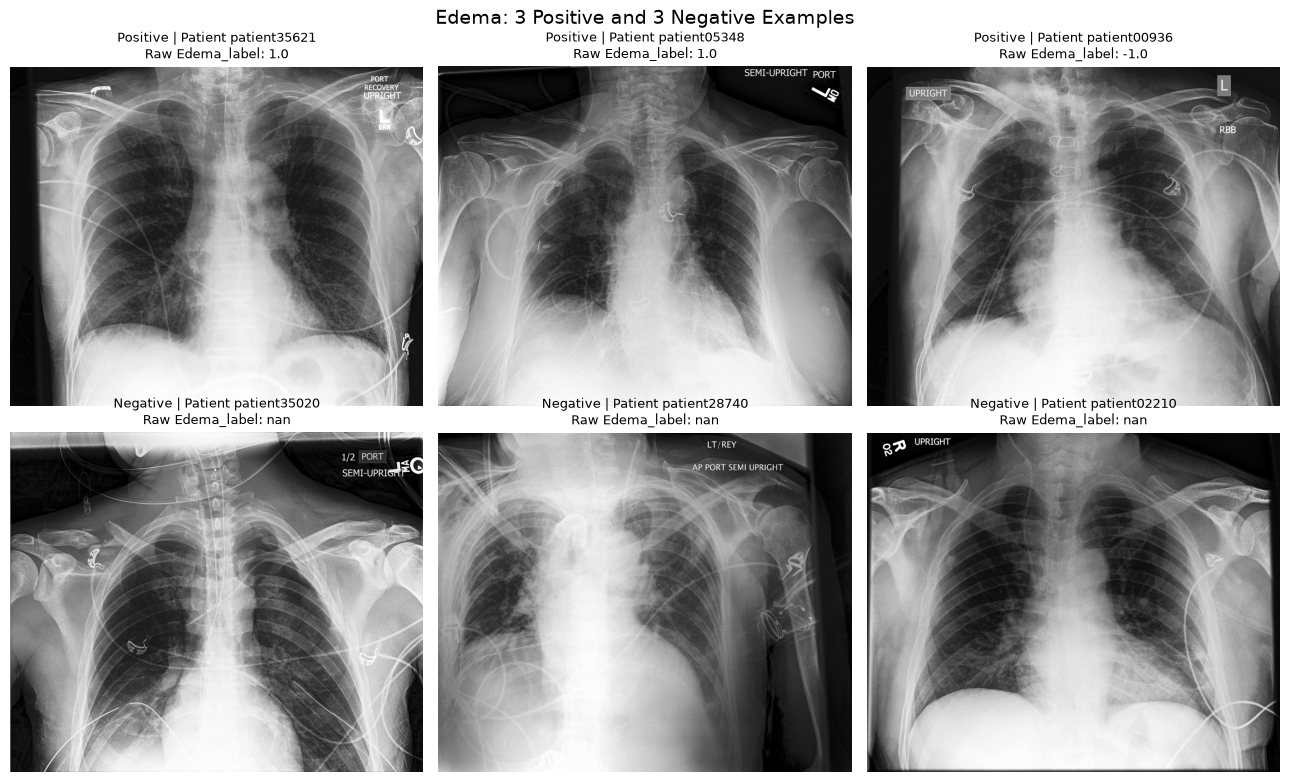

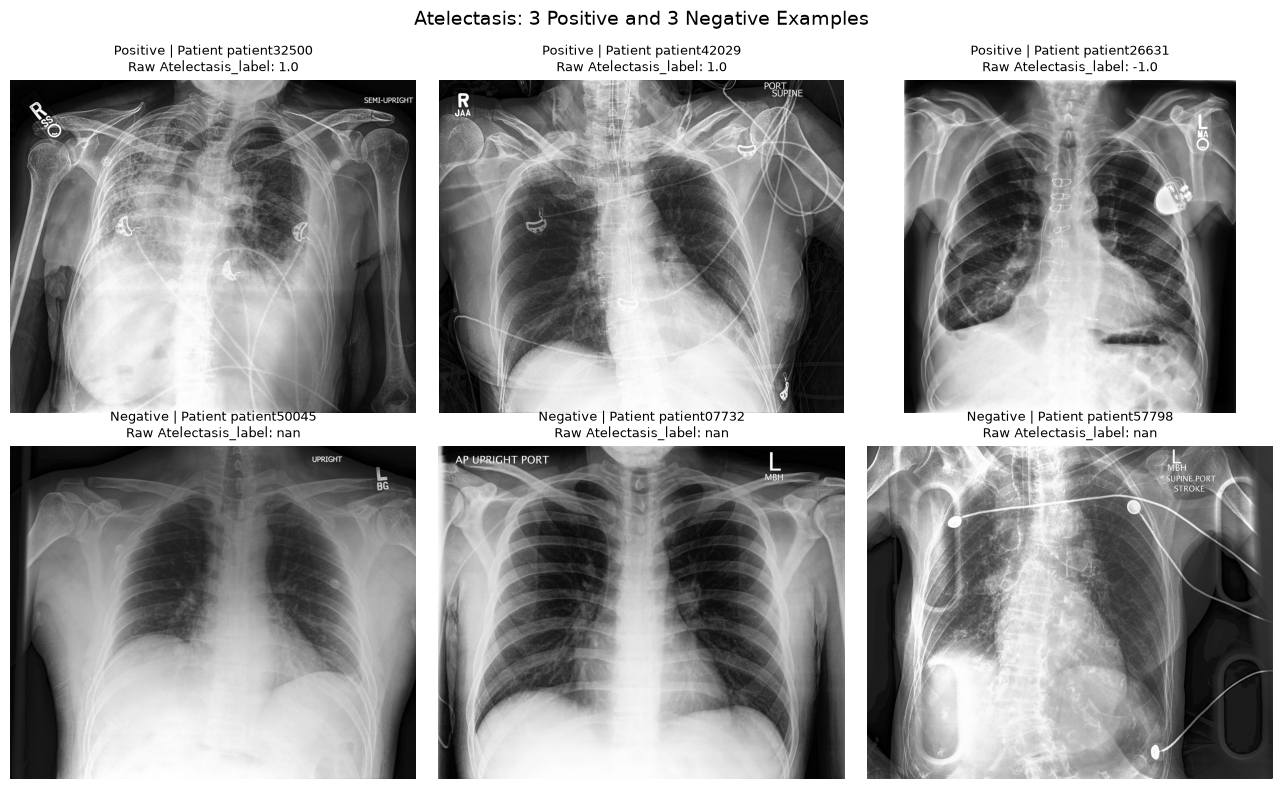

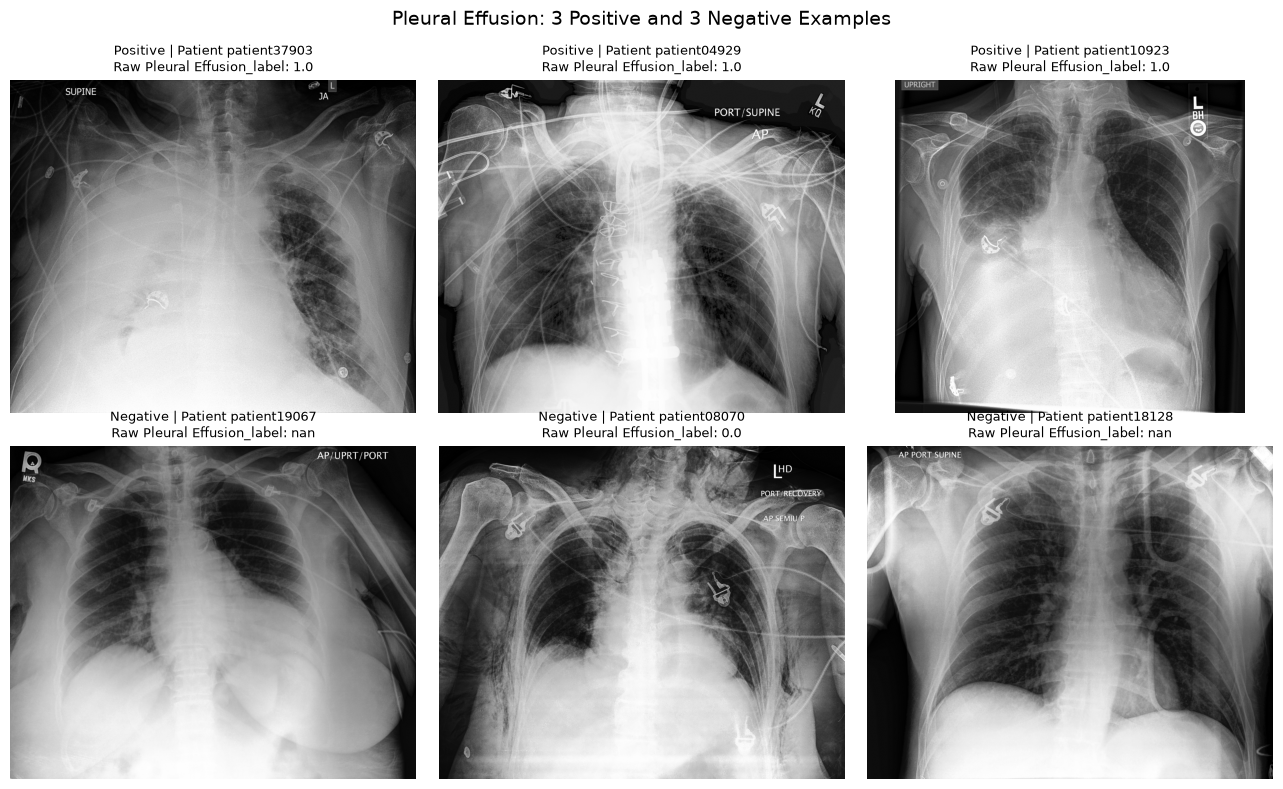

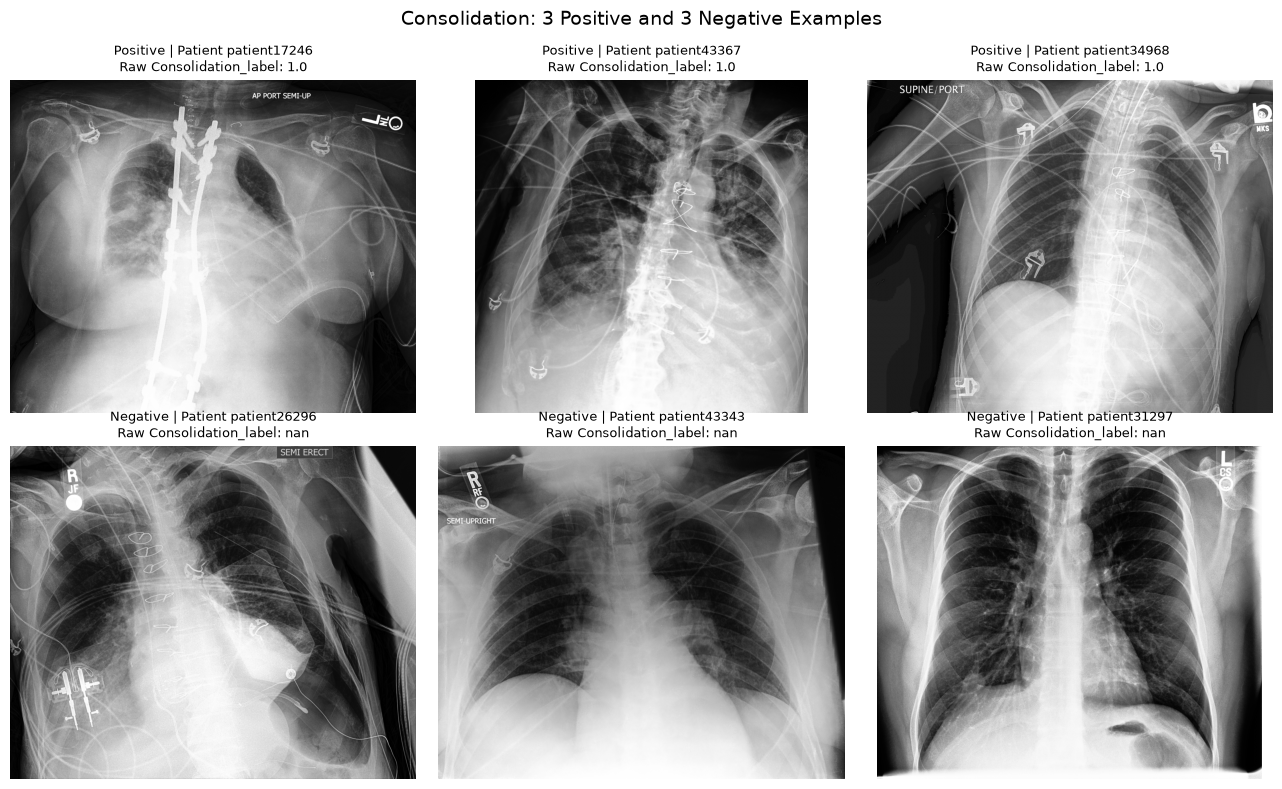

In [11]:
def display_label_examples(frame: pd.DataFrame, label: str, seed: int = 42) -> None:
    raw_label = label.removesuffix('_label') + '_raw'
    positives = frame.loc[frame[label] == 1].sample(n=3, random_state=seed)
    negatives = frame.loc[frame[label] == 0].sample(n=3, random_state=seed)
    examples = pd.concat([positives, negatives], ignore_index=True)
    fig, axes = plt.subplots(2, 3, figsize=(13, 8))
    for axis, (_, row) in zip(axes.flat, examples.iterrows()):
        with Image.open(row['local_image_path']) as image:
            axis.imshow(image, cmap='gray')
        status = 'Positive' if row[label] == 1 else 'Negative'
        axis.set_title(f"{status} | Patient {row['deid_patient_id']}\nRaw {label}: {row[raw_label]}", fontsize=9)
        axis.axis('off')
    fig.suptitle(f'{label.removesuffix("_label")}: 3 Positive and 3 Negative Examples', fontsize=14)
    plt.tight_layout()
    plt.show()

for label_column in LABEL_COLUMNS:
    display_label_examples(manifest, label_column)

**Section 3 summary.** The grids show three fixed-seed positive and three fixed-seed negative local images for each of the five targets, with patient IDs and preserved raw label values. They are intended for qualitative label and image-path sanity checks only, not diagnostic validation or causal interpretation.